In [42]:
library(tidyverse) # dplyr and ggplot2; CRAN
library(Seurat) # Seurat toolkit; CRAN
library(hdf5r) # for data import; CRAN
library(patchwork) # for plotting; CRAN 
library(presto) # for differential expression; Github
library(glmGamPoi) # for sctransform; Bioconductor
library(ggplot2) # for visualization; installed with tidyverse
library(dplyr) #just to make sure it was called; installed with tidyverse


library(SingleR) # for cell type annotation; Bioconductor
library(celldex) # for cell type annotation reference; Bioconductor
library(MAST) # for differential expression; Bioconductor


Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, 

In [2]:
# use multicore parallelism (Linux/SageMaker)
plan("multicore", workers = 8)

# increase memory limit for futures
options(future.globals.maxSize = 12 * 1024^3)  # 12 GB

In [6]:
W10 <- Read10X_h5("/Users/varunshamanna/Github_repos/SC-demo_notebooks/seurat_tutorials/QC/GSE193462_RAW/W10_raw/raw_feature_bc_matrix.h5")

In [7]:
# Single sample
adp <- CreateSeuratObject(counts=W10, project="W10", min.cells = 3,
                          min.features = 200)
# View W10
adp


An object of class Seurat 
19199 features across 37888 samples within 1 assay 
Active assay: RNA (19199 features, 0 variable features)
 1 layer present: counts

In [8]:
head(adp@meta.data) #using head to return only the first 6 rows  

,orig.ident,nCount_RNA,nFeature_RNA
,<fct>,<dbl>,<int>
AAACCCACAATCCTTT-1,W10,326,255
AAACCCACAATTGCAC-1,W10,576,396
AAACCCACACATGAAA-1,W10,287,224
AAACCCACACGTCATA-1,W10,308,229
AAACCCACAGACGCTC-1,W10,262,214
AAACCCACAGCCTACG-1,W10,802,527


In [9]:
#Access a single column. 
head(adp$orig.ident)

AAACCCACAATCCTTT-1 AAACCCACAATTGCAC-1 AAACCCACACATGAAA-1 AAACCCACACGTCATA-1 
               W10                W10                W10                W10 
AAACCCACAGACGCTC-1 AAACCCACAGCCTACG-1 
               W10                W10 
Levels: W10

In [10]:
head(adp[["orig.ident"]])

,orig.ident
,<fct>
AAACCCACAATCCTTT-1,W10
AAACCCACAATTGCAC-1,W10
AAACCCACACATGAAA-1,W10
AAACCCACACGTCATA-1,W10
AAACCCACAGACGCTC-1,W10
AAACCCACAGCCTACG-1,W10


In [11]:
#Access multiple columns, rows. 
head(adp[[c("orig.ident", "nCount_RNA")]])[1:3,]

,orig.ident,nCount_RNA
,<fct>,<dbl>
AAACCCACAATCCTTT-1,W10,326
AAACCCACAATTGCAC-1,W10,576
AAACCCACACATGAAA-1,W10,287


In [12]:
adp$condition <- ifelse(str_detect(adp@meta.data$orig.ident, "^W"),
                        "WT","DKO")


In [13]:
adp$time_point <- ifelse(str_detect(adp@meta.data$orig.ident, "0"),
                         "Day 0","Day 6")

In [14]:
head(Features(adp))

[1] "Xkr4"    "Gm19938" "Rp1"     "Sox17"   "Mrpl15"  "Lypla1"

In [15]:
Assays(adp)


[1] "RNA"

In [16]:
#return number of cells across all layers
num_cells <- ncol(adp)
#return number of features across all layers
num_features <- nrow(adp)
#to return row by column information
dim(adp)


[1] 19199 37888

Warning message:
“The dot-dot notation (`..count..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(count)` instead.”


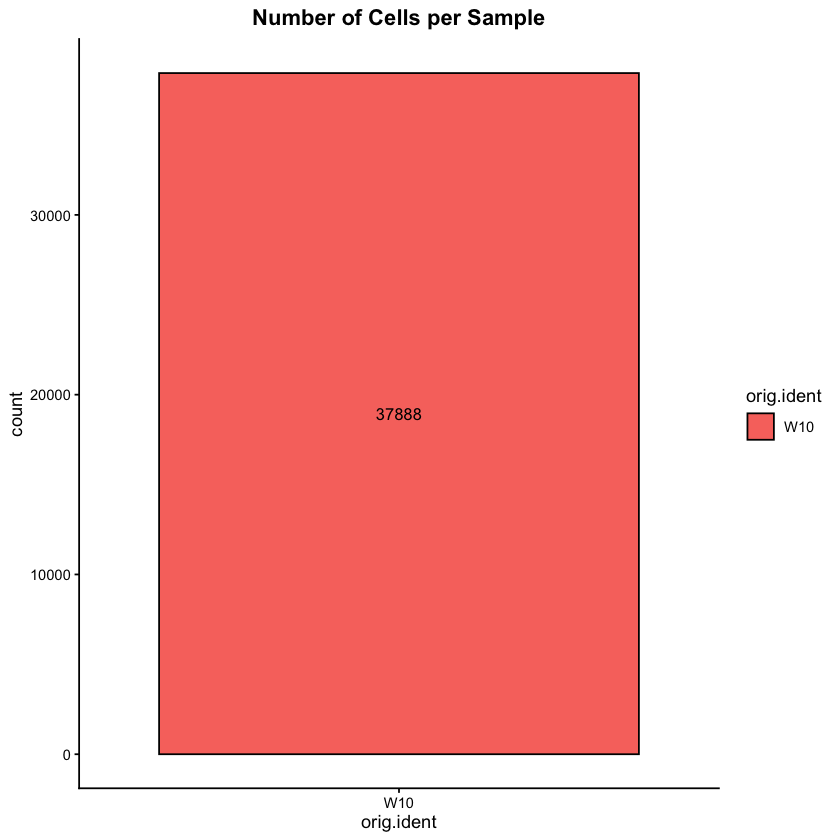

In [17]:
# Visualize the number of cell counts per sample
adp@meta.data %>% 
  ggplot(aes(x=orig.ident, fill=orig.ident)) + 
  geom_bar(color="black") +
  stat_count(geom = "text", colour = "black", size = 3.5, 
            aes(label = ..count..),
            position=position_stack(vjust=0.5))+
  theme_classic() +
  theme(plot.title = element_text(hjust=0.5, face="bold")) +
  ggtitle("Number of Cells per Sample")


In [18]:
adp[["percent.mt"]] <- PercentageFeatureSet(adp, pattern = "^mt-")

In [19]:
metadata <- adp@meta.data

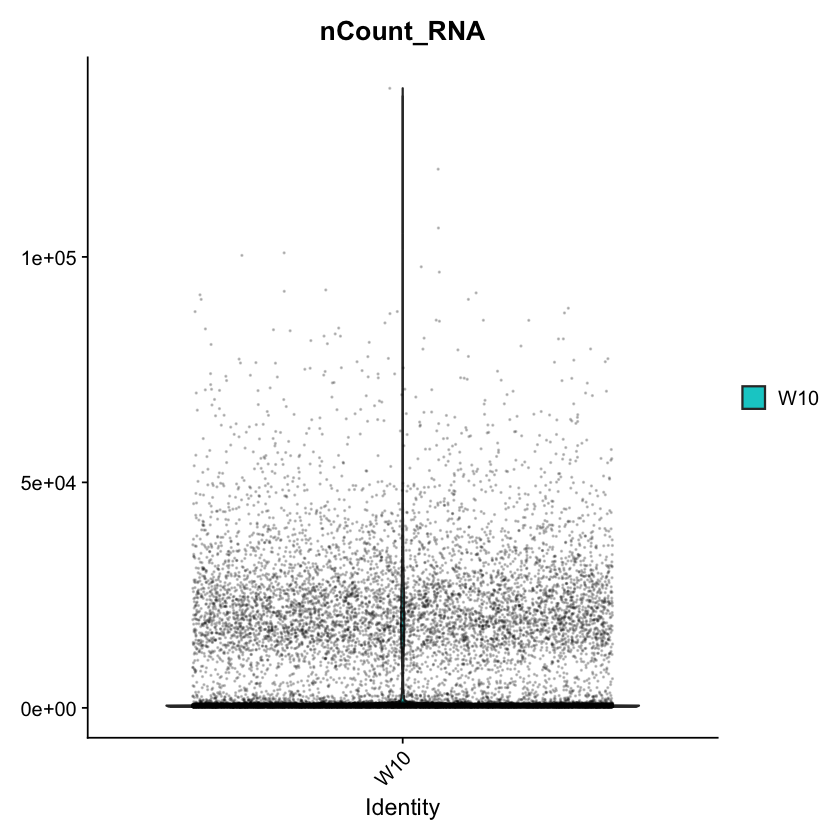

In [20]:
# set colors
cnames<-setNames(rep(c("cyan3","darkgoldenrod1"),each=4),levels(factor(metadata$orig.ident))) 

# plot
VlnPlot(adp, features = "nCount_RNA", layer="counts", group.by="orig.ident",raster=FALSE,alpha=0.2) +
  scale_fill_manual(values=cnames) 

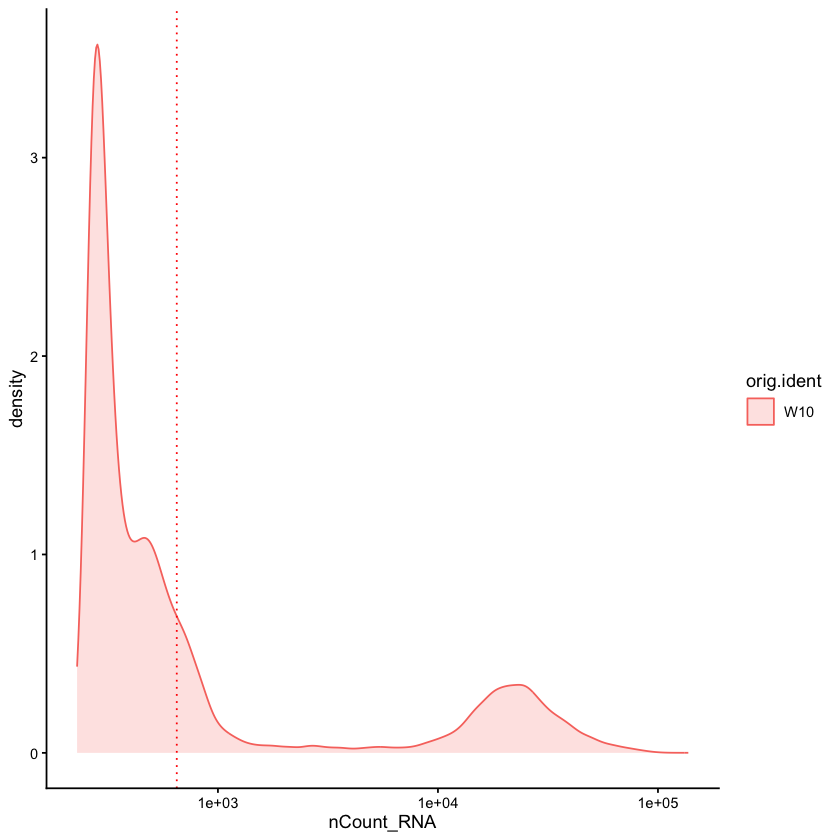

In [21]:
metadata %>% 
    ggplot(aes(color=orig.ident, x=nCount_RNA, fill= orig.ident)) + 
    geom_density(alpha = 0.2) + 
    theme_classic() +
    scale_x_log10() + 
    geom_vline(xintercept = 650,color="red",linetype="dotted")


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


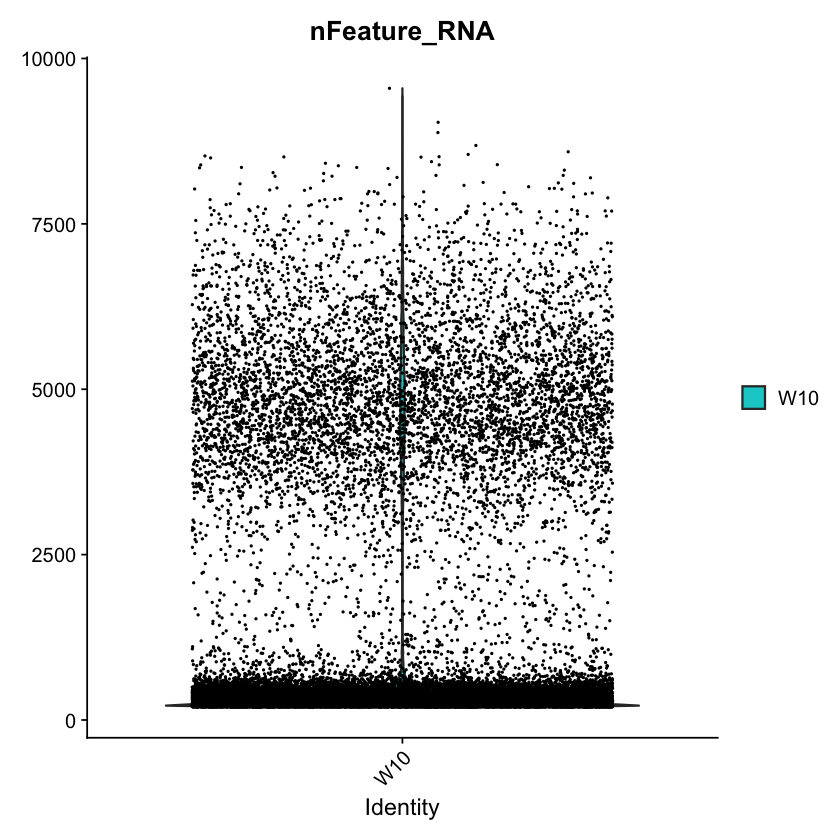

In [22]:
VlnPlot(adp, features = "nFeature_RNA", group.by="orig.ident") +
  scale_fill_manual(values=cnames) 

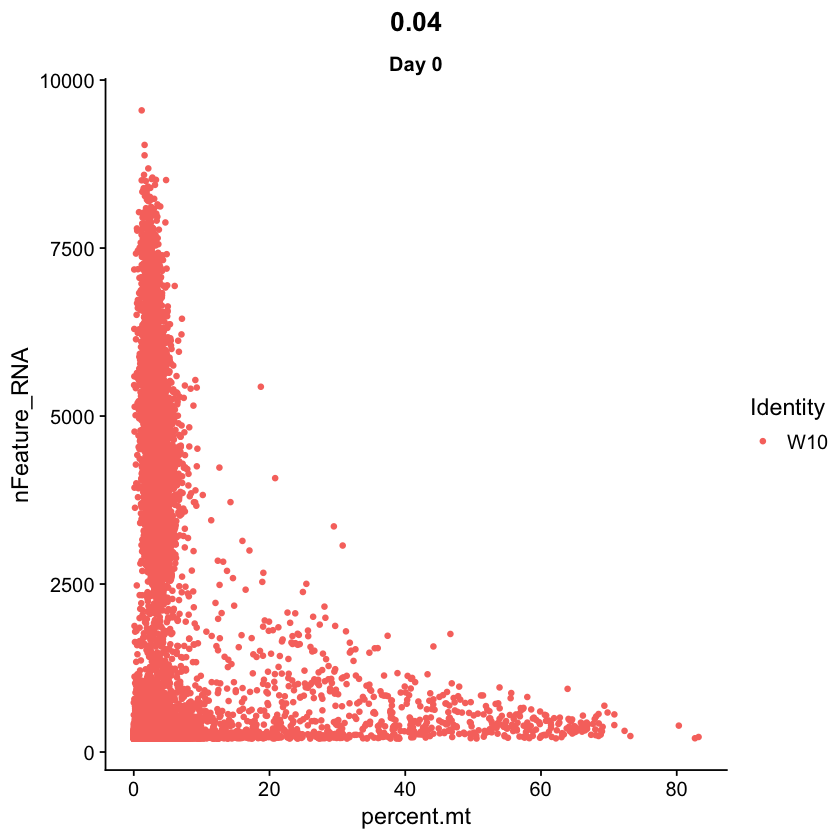

In [23]:
FeatureScatter(adp, feature1 = "percent.mt", feature2 ="nFeature_RNA" , group.by="orig.ident",split.by="time_point") 


In [ ]:
# OR use the same parameters across all samples
adp_filt <- subset(adp, nFeature_RNA > 350 &
                   nCount_RNA > 650 & percent.mt < 10)


In [ ]:
adp_filt <- SCTransform(adp_filt,
                        vars.to.regress = "percent.mt",
                        verbose = FALSE)

In [ ]:
adp_filt <- RunPCA(adp_filt, verbose = FALSE, assay = "SCT")

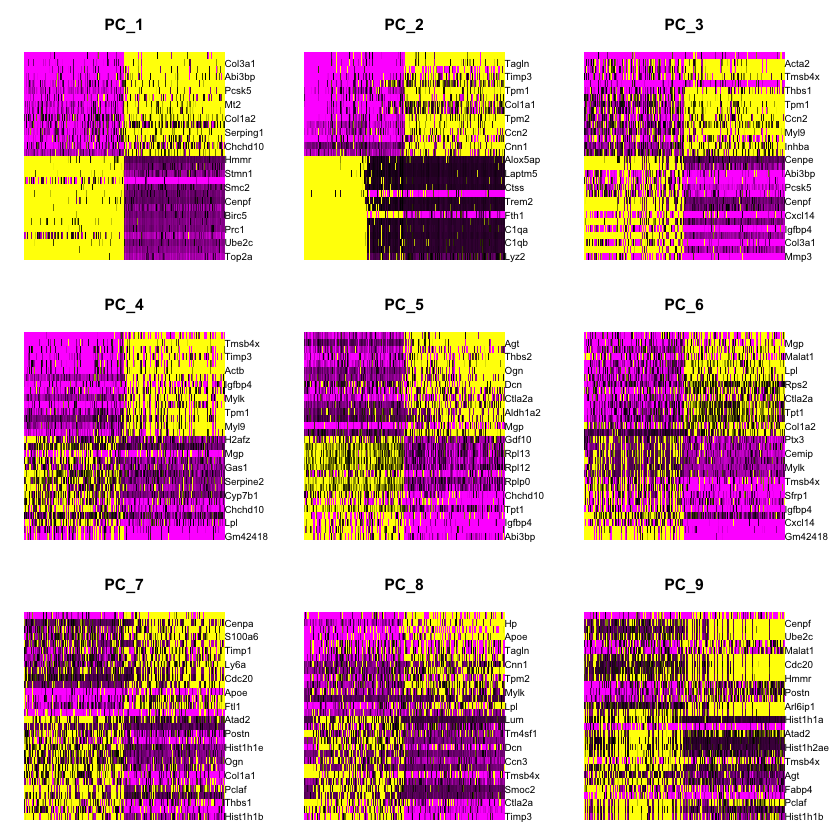

In [ ]:
# dimensions 1 to 9
DimHeatmap(adp_filt, dims = 1:9, cells = 500, balanced = TRUE, ncol = 3)

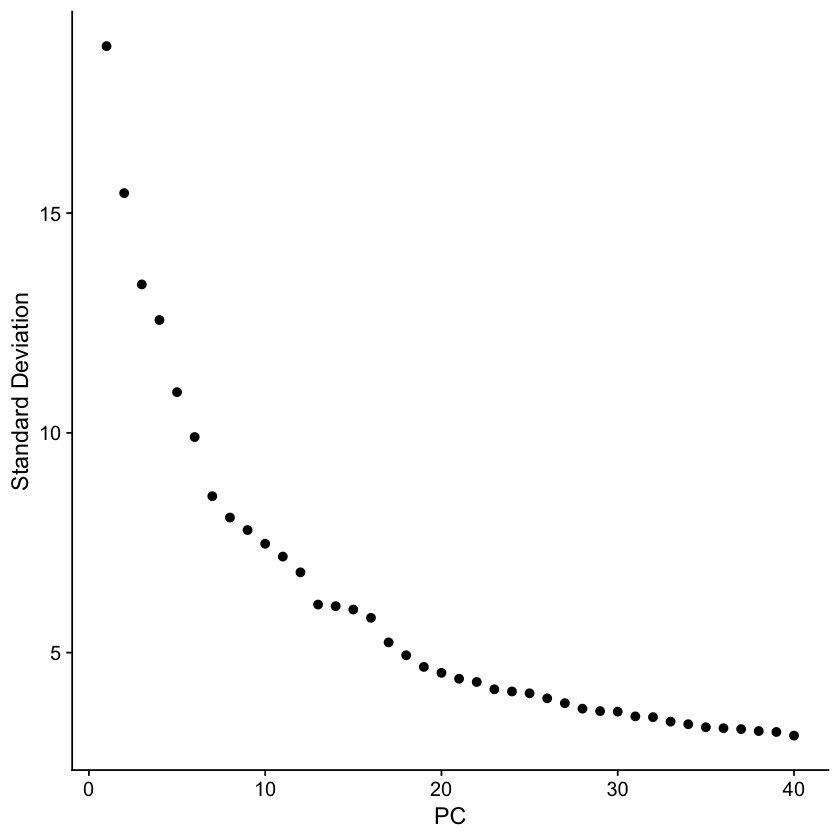

In [30]:
ElbowPlot(adp_filt, ndims = 40)

In [31]:
adp_filt <- FindNeighbors(adp_filt, dims = 1:30)

Computing nearest neighbor graph

Computing SNN



In [32]:
adp_filt <- FindClusters(adp_filt, resolution = 0.1)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 9959
Number of edges: 350836

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9509
Number of communities: 6
Elapsed time: 0 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future ‘future_lapply-1’ (dd59370c406584998f89e4e9ed96c0c5-49); on dd59370c406584998f89e4e9ed96c0c5@arm64-apple-darwin20.0.0<13493>]”


In [33]:
adp_filt <- RunUMAP(adp_filt,dims = 1:30)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
19:55:51 UMAP embedding parameters a = 0.9922 b = 1.112

19:55:51 Read 9959 rows and found 30 numeric columns

19:55:51 Using Annoy for neighbor search, n_neighbors = 30

19:55:51 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

19:55:51 Writing NN index file to temp file /var/folders/yp/rq67n9wd35vfkdbx07pvj2k80000gp/T//RtmpnCo130/file34b57008174c

19:55:51 Searching Annoy index using 8 threads, search_k = 3000

19:55:52 Annoy recall = 100%

19:55:52 Commencing smooth kNN distance calibra

Warning message:
“The following requested variables were not found: cond_tp”


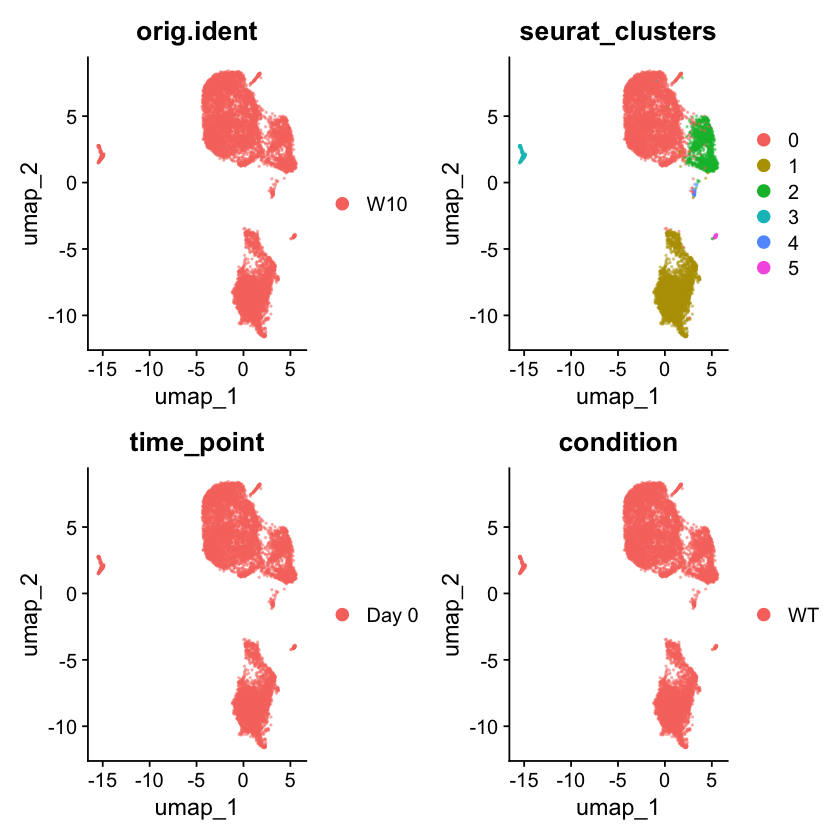

In [34]:
DimPlot(adp_filt, reduction = "umap",
        group.by = c("orig.ident",
                     "seurat_clusters",
                     "time_point",
                     "condition",
                     "cond_tp"),
        alpha = 0.4, ncol = 2)

In [ ]:
adp_filt <- PrepSCTFindMarkers(adp_filt, verbose=T)

Only one SCT model is stored - skipping recalculating corrected counts



In [36]:
#requires presto installation to speed up the next step
#devtools::install_github('immunogenomics/presto')
library(presto)
# find all markers
adp_filt_markers <- FindAllMarkers(adp_filt, only.pos = TRUE)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5



In [37]:
#ordering the results
adp_filt_markers <- adp_filt_markers %>% 
  arrange(cluster,desc(avg_log2FC), desc(p_val_adj))

#examine a small subset
adp_filt_markers %>%
  group_by(cluster) %>%
  slice_max(n = 5, order_by = avg_log2FC)

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
2.842312e-13,4.038808,0.012,0.000,5.120710e-09,0,Pdlim3
5.757747e-06,4.012813,0.027,0.014,1.037316e-01,0,Cfd
8.111166e-12,3.968419,0.011,0.001,1.461308e-07,0,2600014E21Rik
1.342634e-140,3.883748,0.167,0.020,2.418889e-136,0,Mlana
4.365967e-10,3.857715,0.011,0.001,7.865726e-06,0,Plin1
0.000000e+00,3.260271,1.000,1.000,0.000000e+00,1,Gm42418
0.000000e+00,3.229454,0.999,0.835,0.000000e+00,1,AY036118
0.000000e+00,1.896676,0.998,0.682,0.000000e+00,1,Lars2
2.626813e-224,0.642581,0.942,0.495,4.732467e-220,1,Gm2000


Warning message in DoHeatmap(adp_filt, features = top20$gene):
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: Ppp1r16b, Podxl, Cmtm8, She, Dapk2, Tmem252, Sox17, Tie1, Nrarp, Sox2ot, Mpz, Tfap2b, Fgf5, Itgb8, Ttyh1, Sox2, Hcn1, Cfap299, Foxd3, Ppp1r14c, Slc22a23, Sox6, Gjc3, Crym, Cdh19, Ajap1, Slc35f1, Epha5, Mal, Dok2, Myo1f, Clec4e, Dock2, Tnfaip8l2, Ptpn6, Sapcd2, Kif18b, Hist1h2bb, Tube1, Gm38037, Arhgef39, Hist1h3b, Pif1, C7, Tcp11l2, Olfr1033, Gm17167, Vtn, Steap4, 2600014E21Rik, Pdlim3”


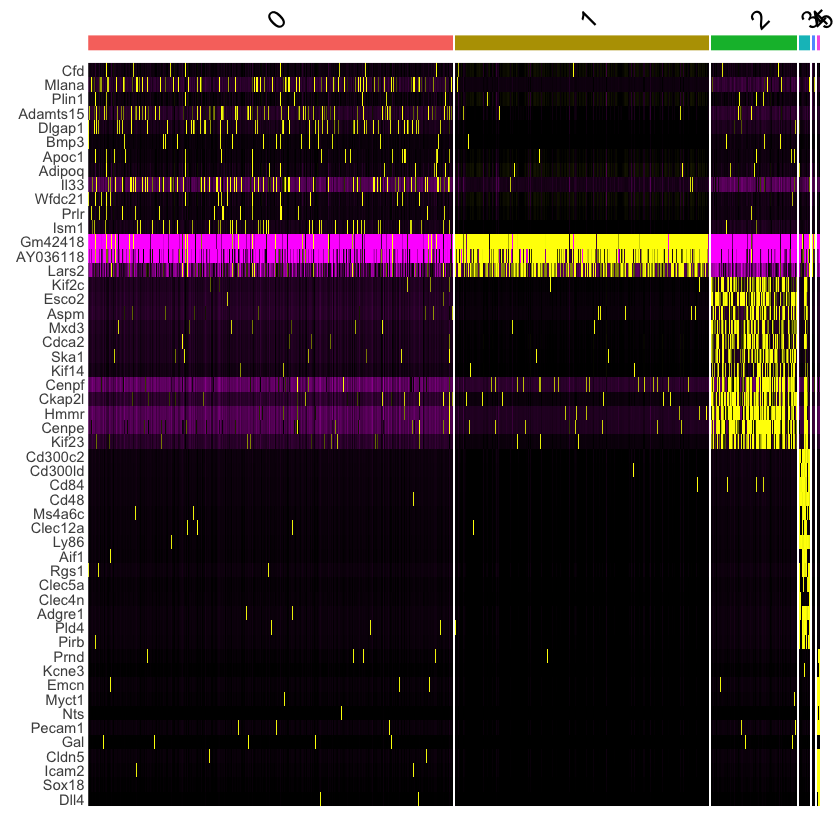

In [38]:
top20<-adp_filt_markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 20) %>%
    ungroup() 
DoHeatmap(adp_filt, features = top20$gene) + NoLegend()

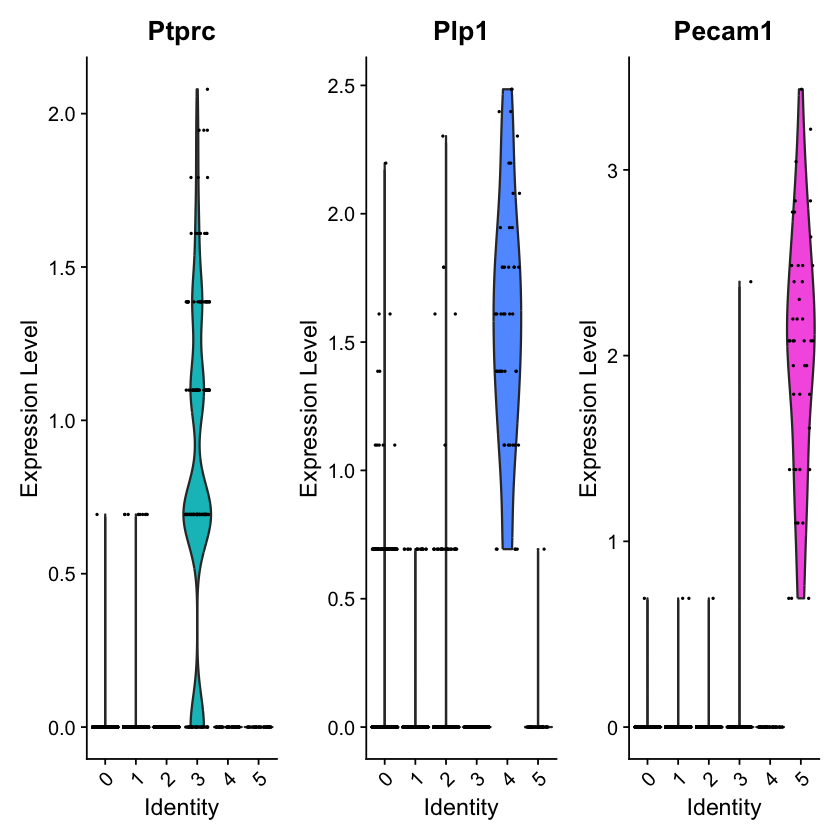

In [39]:
#contaminants
contam=c("Ptprc", "Plp1", "Pecam1")
#beige adipocytes
beige=c("Ucp1","Ppargc1a","Elovl3","Cidea")
#preadipocytes
preadip<-c('Mmp3', 'Cd142', 'Itgb1')
#proliferating
prolif<-'Mki67'
#differentiating adipocytes
diffadip<-c('Col5a3', 'Serpina3n')

VlnPlot(adp_filt, features=contam)


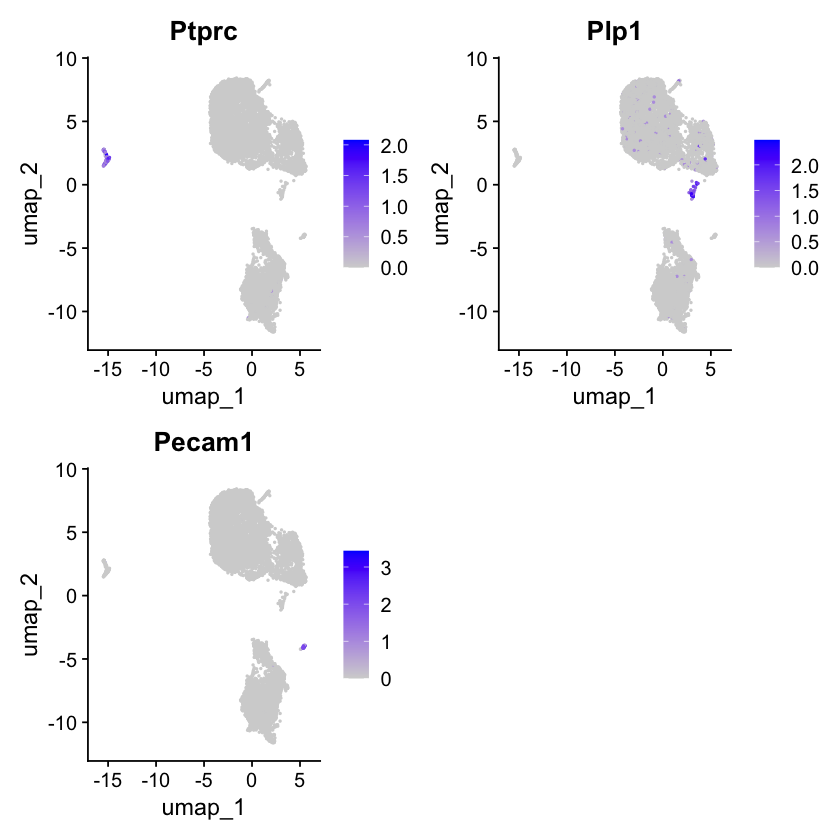

In [ ]:
FeaturePlot(adp_filt, features = contam)

Warning message:
“The following requested variables were not found: cond_tp”


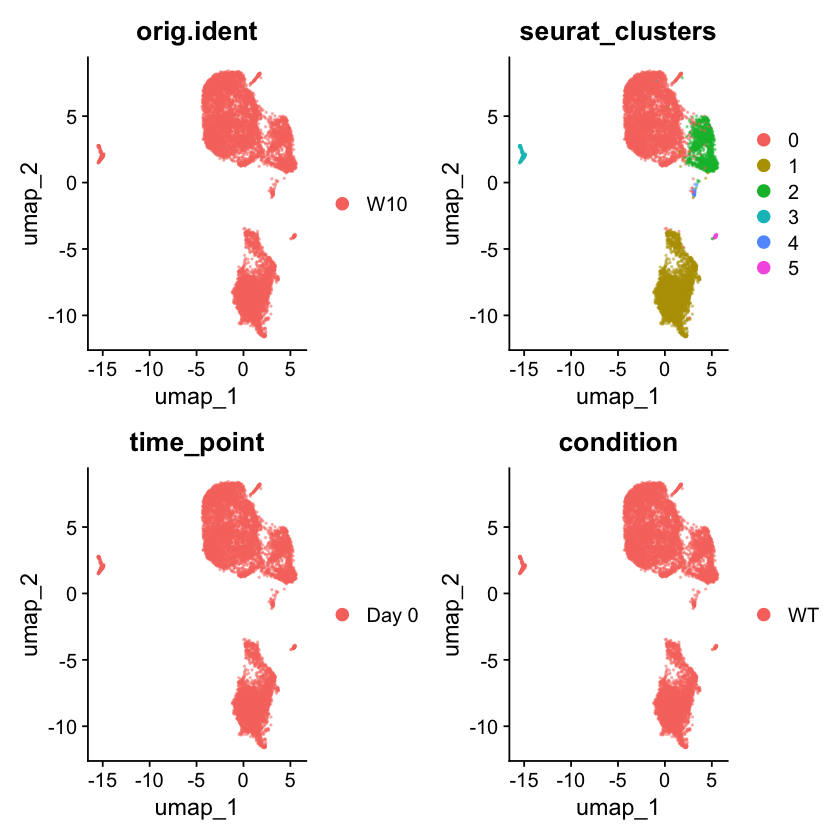

In [44]:
DimPlot(adp_filt, reduction = "umap", group.by = c("orig.ident", "seurat_clusters","time_point","condition","cond_tp"),
        alpha=0.4, ncol=2)

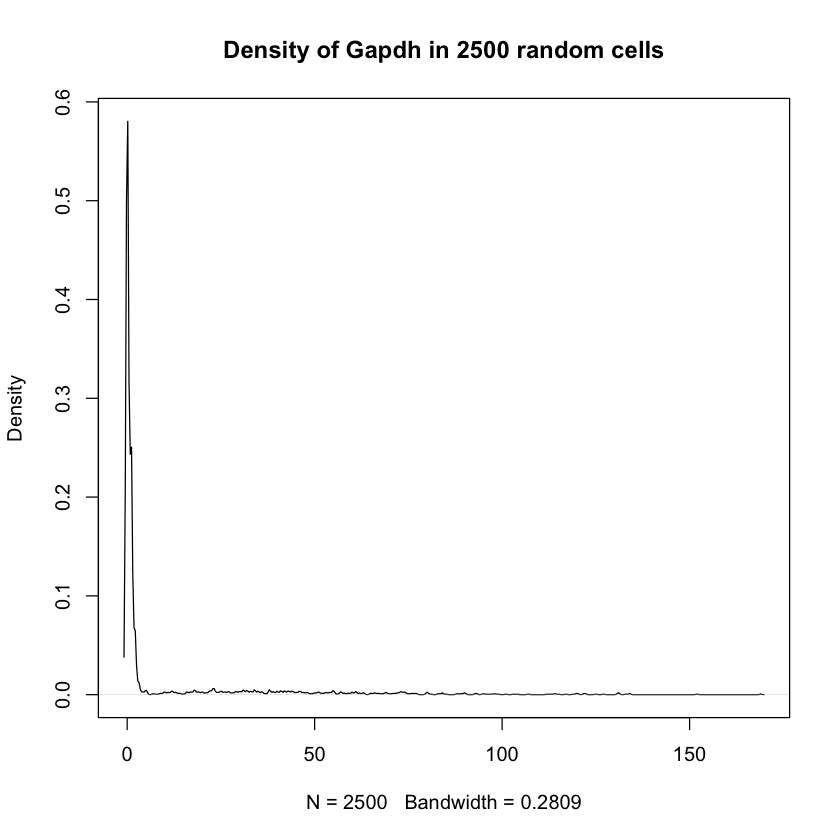

In [45]:
plot(density(sample(JoinLayers(adp@assays$RNA)$count["Gapdh",],2500)),cex=0,lty=1, main="Density of Gapdh in 2500 random cells")

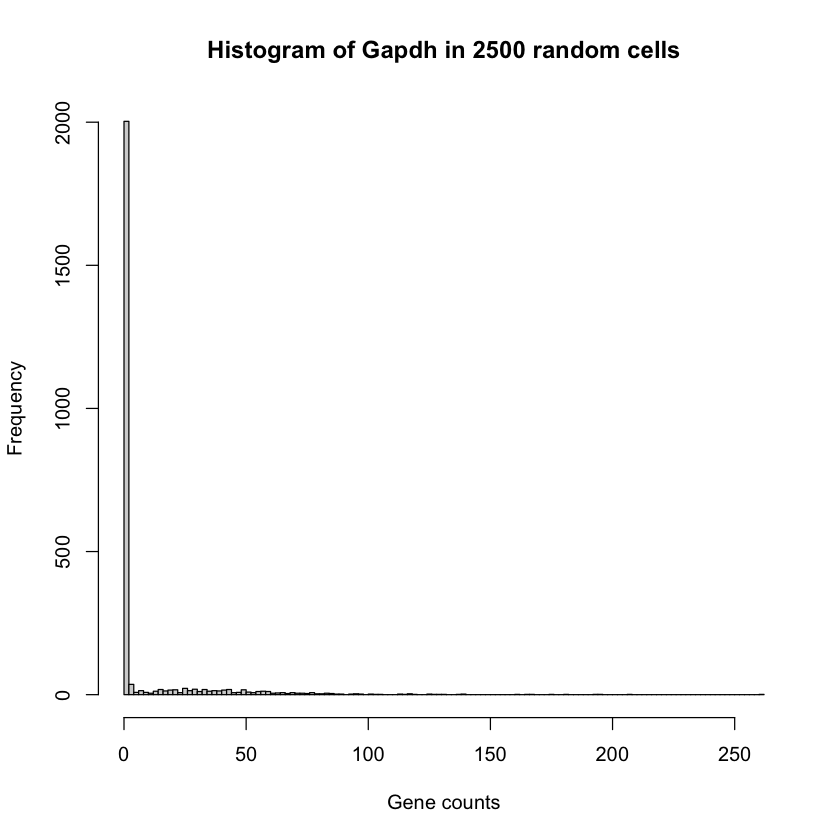

In [47]:
hist(sample(JoinLayers(adp@assays$RNA)$count["Gapdh",],2500),breaks=99,main="Histogram of Gapdh in 2500 random cells",ylab="Frequency",xlab="Gene counts")


In [49]:
adp_filt = PrepSCTFindMarkers(adp_filt)

Only one SCT model is stored - skipping recalculating corrected counts



In [51]:
de_allClusters = FindAllMarkers(adp_filt, test.use="wilcox", min.pct=0.1, only.pos=TRUE)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5



In [52]:
head(de_allClusters)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
Tmem87b,0,2.2323826,0.488,0.104,0,0,Tmem87b
Clip3,0,2.1656148,0.474,0.104,0,0,Clip3
Tcea3,0,2.6220820,0.409,0.073,0,0,Tcea3
Aebp1,0,0.7094395,0.998,0.988,0,0,Aebp1
Col1a2,0,0.7697447,1.000,0.999,0,0,Col1a2
Sparc,0,0.8343157,1.000,0.999,0,0,Sparc


In [53]:
nrow(de_allClusters)

[1] 22095

In [54]:
top5PerCluster = matrix(ncol=7)
colnames(top5PerCluster) = colnames(de_allClusters)
for (i in 0:7){
  top5PerCluster = rbind(top5PerCluster, head(de_allClusters[which(de_allClusters$cluster==i),], 5))
}
top5PerCluster=top5PerCluster[-1,]
top5PerCluster

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Tmem87b,0.000000e+00,2.2323826,0.488,0.104,0.000000e+00,0,Tmem87b
Clip3,0.000000e+00,2.1656148,0.474,0.104,0.000000e+00,0,Clip3
Tcea3,0.000000e+00,2.6220820,0.409,0.073,0.000000e+00,0,Tcea3
Aebp1,0.000000e+00,0.7094395,0.998,0.988,0.000000e+00,0,Aebp1
Col1a2,0.000000e+00,0.7697447,1.000,0.999,0.000000e+00,0,Col1a2
Lars2,0.000000e+00,1.8966765,0.998,0.682,0.000000e+00,1,Lars2
AY036118,0.000000e+00,3.2294543,0.999,0.835,0.000000e+00,1,AY036118
Gm42418,0.000000e+00,3.2602705,1.000,1.000,0.000000e+00,1,Gm42418
Gm2000,2.626813e-224,0.6425810,0.942,0.495,4.732467e-220,1,Gm2000


Warning message in DoHeatmap(adp_filt, features = top5PerCluster$gene, slot = "scale.data"):
“The following features were omitted as they were not found in the scale.data layer for the SCT assay: Edil3, Fgf5, Gm2000, Clip3”


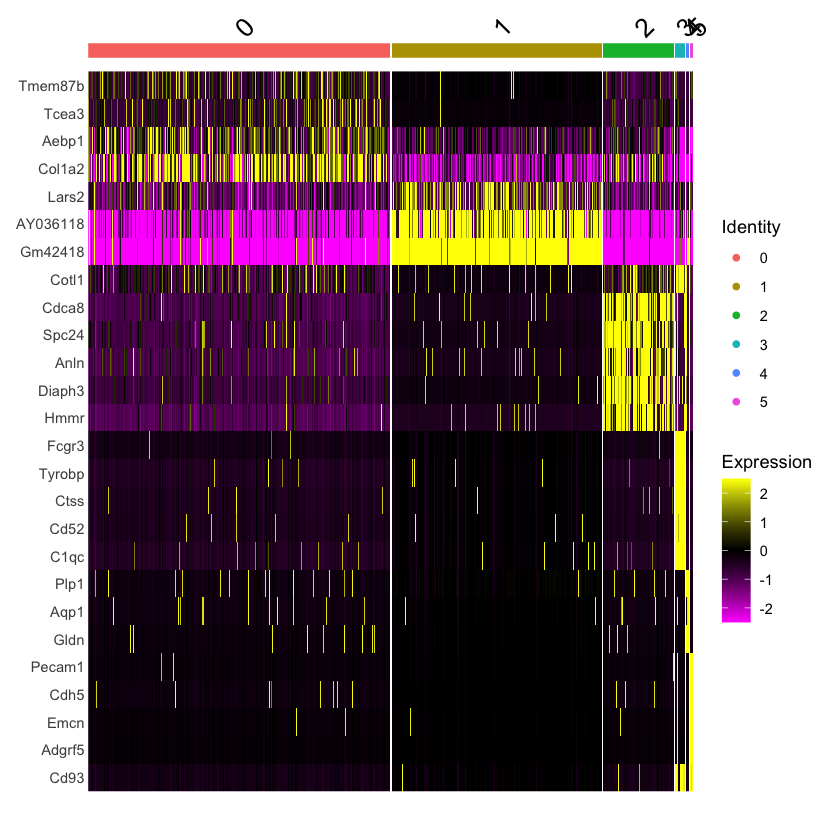

In [55]:
DoHeatmap(adp_filt,features = top5PerCluster$gene,slot="scale.data")

In [59]:
head(adp_filt[["orig.ident"]])

,orig.ident
,<fct>
AAACCCACAGCCTACG-1,W10
AAACCCACAGTGACCC-1,W10
AAACCCACATGGCTGC-1,W10
AAACCCAGTGATATAG-1,W10
AAACCCAGTGGAAGTC-1,W10
AAACGAACAGGCCTGT-1,W10


In [64]:
all_markers <- FindAllMarkers(
  adp_filt,
  test.use = "wilcox",
  min.pct = 0.1,
  logfc.threshold = 0.25
)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5



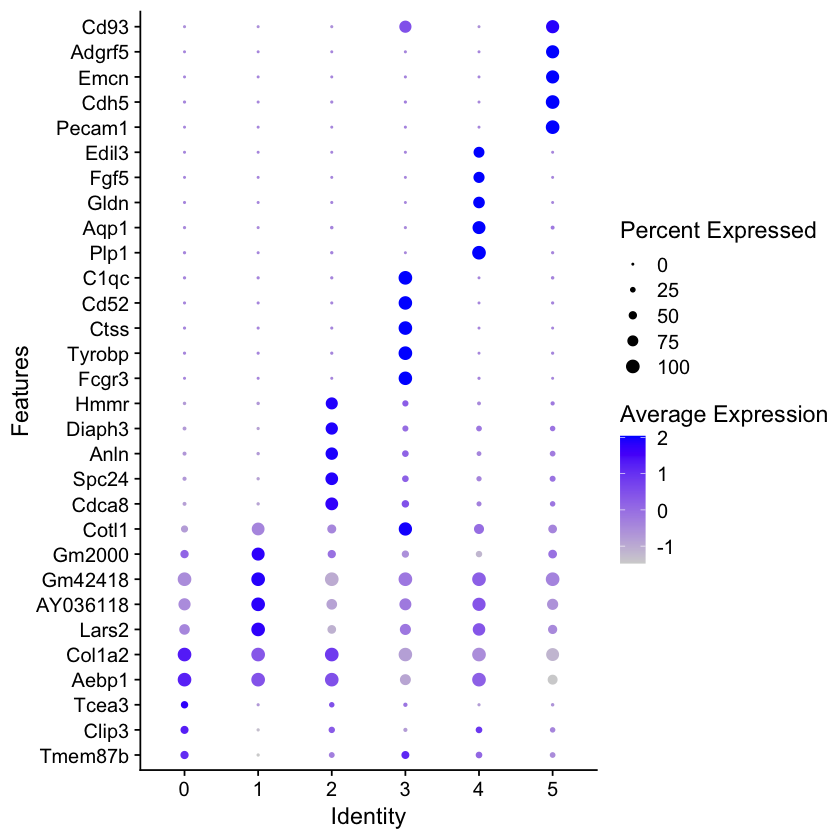

In [65]:
Idents(adp_filt)="SCT_snn_res.0.1"
DotPlot(adp_filt,features=unique(top5PerCluster$gene),dot.scale = 3)+coord_flip()


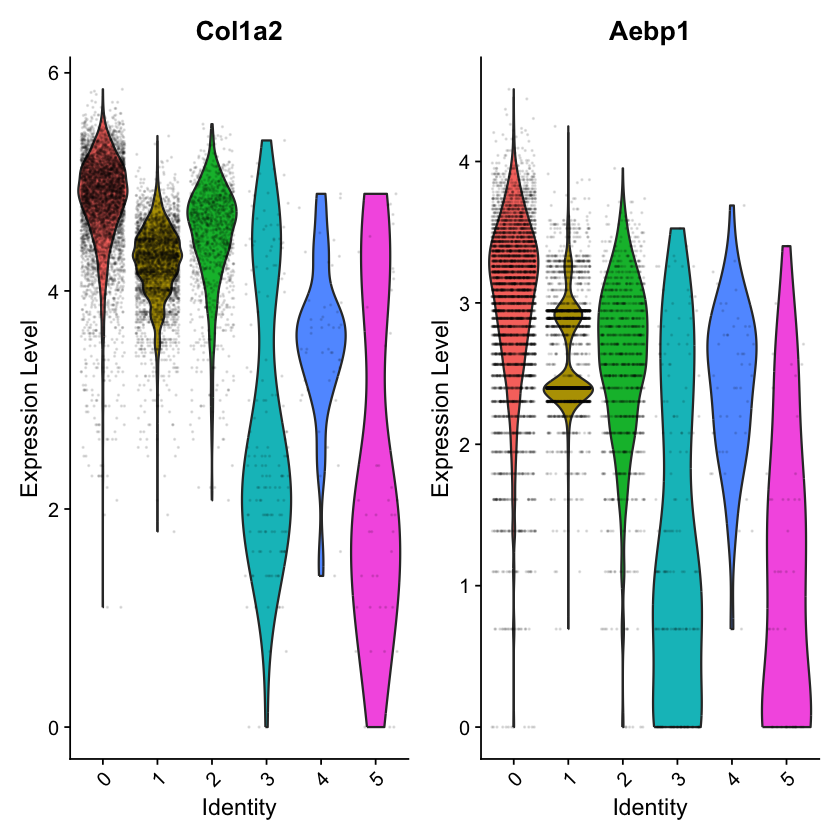

In [66]:
Idents(adp_filt)="SCT_snn_res.0.1"
VlnPlot(adp_filt,features=c("Col1a2","Aebp1"),alpha = 0.1)

In [ ]:
markers <- c(
  # your adipocyte program
  "Mmp3","Mki67","Fabp4","Scd1","Ucp1","Ppargc1a","Elovl3","Cidea",

  # cluster 5....endothelial
  "Cd93","Adgrf5","Emcn","Cdh5","Pecam1",

  # myeloid
  "C1qc","Cd52","Ctss","Tyrobp","Fcgr3",

  # mesenchymal / cycling
  "Hmmr","Diaph3","Anln","Spc24","Cdca8",

  # cluster 0....stromal
  "Col1a2","Aebp1","Tcea3","Clip3","Tmem87b"
)

In [69]:
Idents(adp_filt) <- "SCT_snn_res.0.1"

avgExp <- AverageExpression(
  adp_filt,
  features = markers,
  assay = "SCT"
)$SCT

Warning message:
“The following 1 features were not found in the SCT assay: Ucp1”


Warning message:
“The following requested variables were not found: Ucp1”


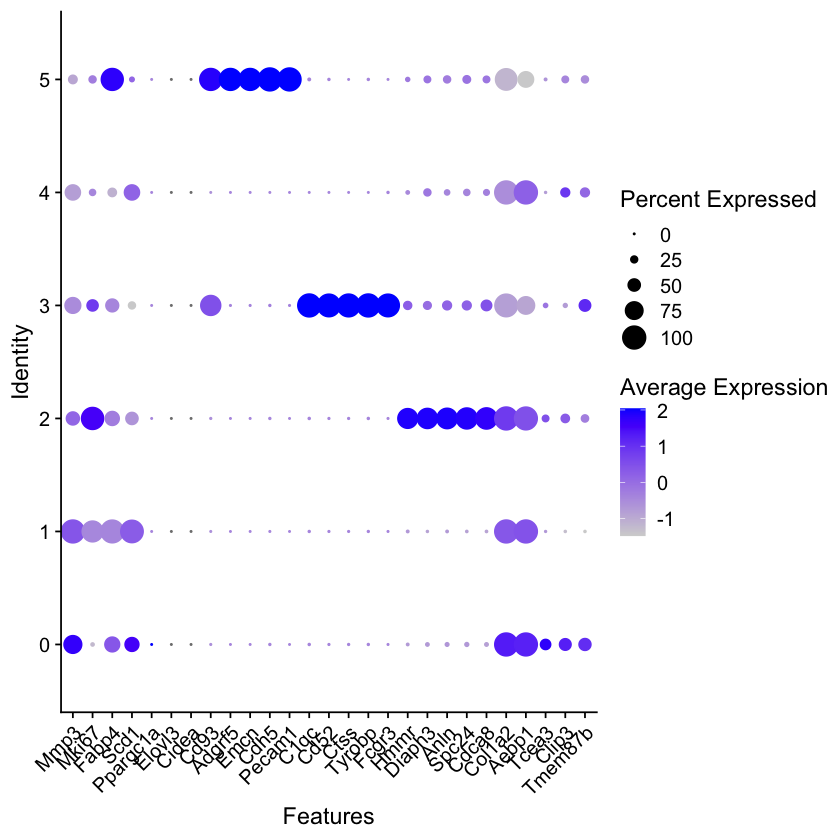

In [70]:
DotPlot(adp_filt, features = markers) +
  RotatedAxis()

In [71]:
avgExp

27 x 6 sparse Matrix of class "dgCMatrix"
                   g0           g1           g2          g3         g4
Mmp3     1.864978e+01 6.923165e+00 5.558848e+00  3.30065359  2.5106383
Mki67    1.253476e-01 1.037132e+00 7.922100e+00  4.30718954  1.0425532
Fabp4    6.447557e+00 2.740931e+00 3.225233e+00  2.71895425  1.0000000
Scd1     2.399086e+00 1.413310e+00 8.712955e-01  0.50326797  1.3404255
Ppargc1a 1.986492e-04 .            .             .           .        
Elovl3   .            .            .             .           .        
Cidea    .            .            .             .           .        
Cd93     8.541915e-03 4.570123e-03 1.270110e-02  1.98039216  .        
Adgrf5   7.945967e-04 .            1.693480e-03  0.01960784  .        
Emcn     3.972984e-04 .            2.540220e-03  0.03921569  .        
Cdh5     2.284466e-02 5.427021e-03 2.370872e-02  0.18300654  .        
Pecam1   1.986492e-04 5.712654e-04 8.467401e-04  0.06535948  .        
C1qc     2.542710e-02 2.427878e-02 

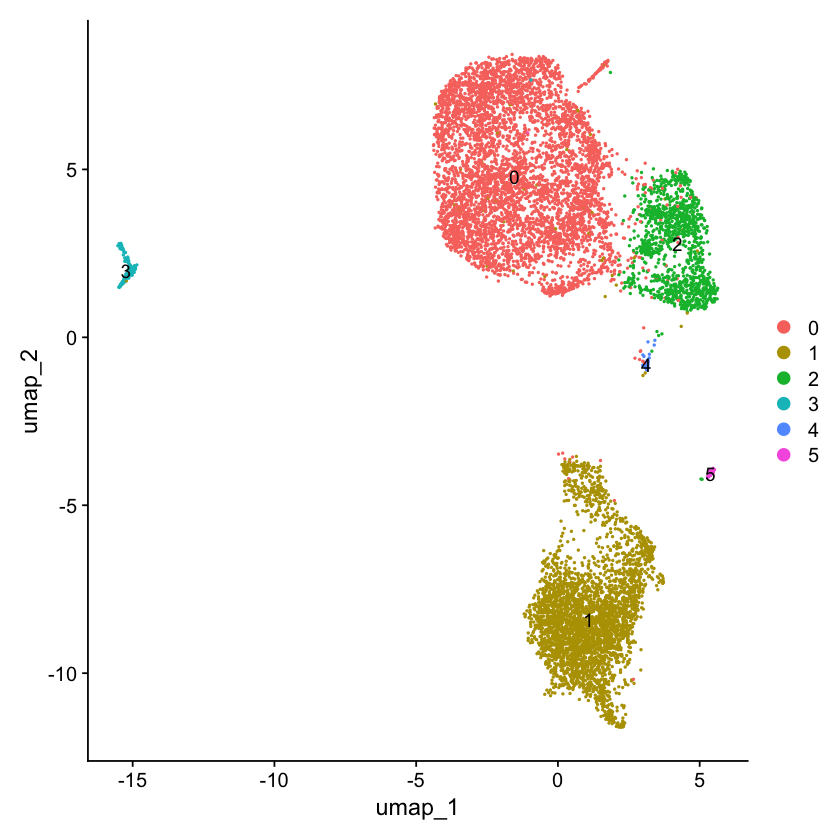

In [72]:
DimPlot(adp_filt,label=T)

In [78]:
Idents(adp) <- "SCT_snn_res.0.1"

adp_filt$adipocyte <- "Unclassified"

# adipocyte lineage
adp_filt$adipocyte[Idents(adp_filt) %in% c(0,1)] <- "Preadipocytes"
adp_filt$adipocyte[Idents(adp_filt) %in% c(2)]   <- "Proliferating cells"
adp_filt$adipocyte[Idents(adp_filt) %in% c(4)]   <- "Differentiating adipocytes"

# contaminants
adp_filt$adipocyte[Idents(adp_filt) %in% c(3)]   <- "Myeloid cells"
adp_filt$adipocyte[Idents(adp_filt) %in% c(5)]   <- "Endothelial cells"

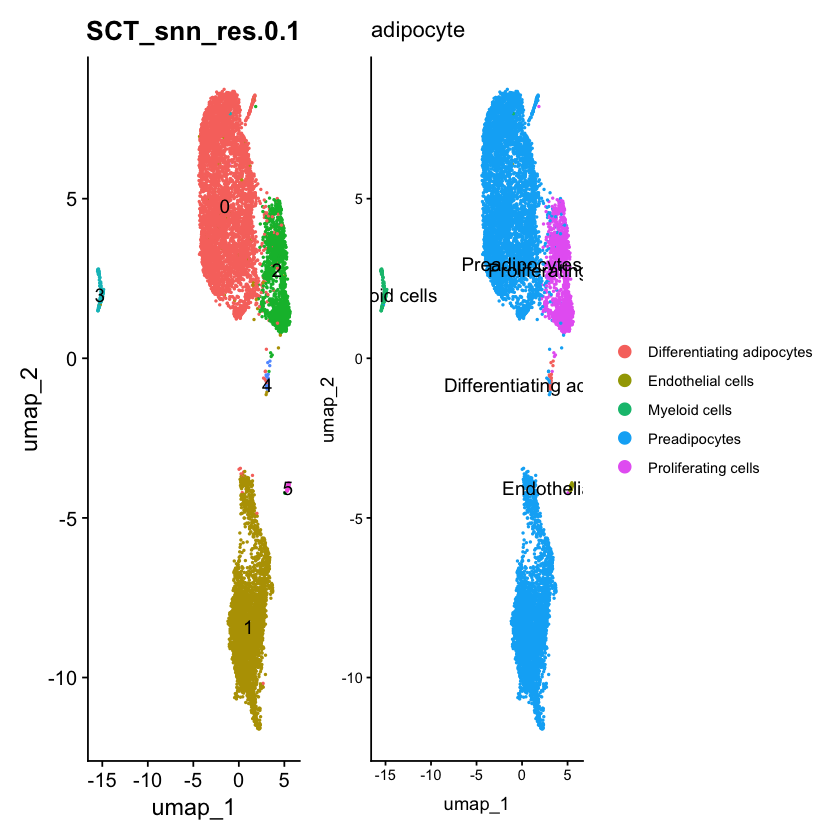

In [86]:
f1 <- DimPlot(adp_filt, group.by = "SCT_snn_res.0.1", label = TRUE) + NoLegend()

f2 <- DimPlot(adp_filt, group.by = "adipocyte", label = TRUE) + NoLegend()

f1 | f2 & theme_classic()

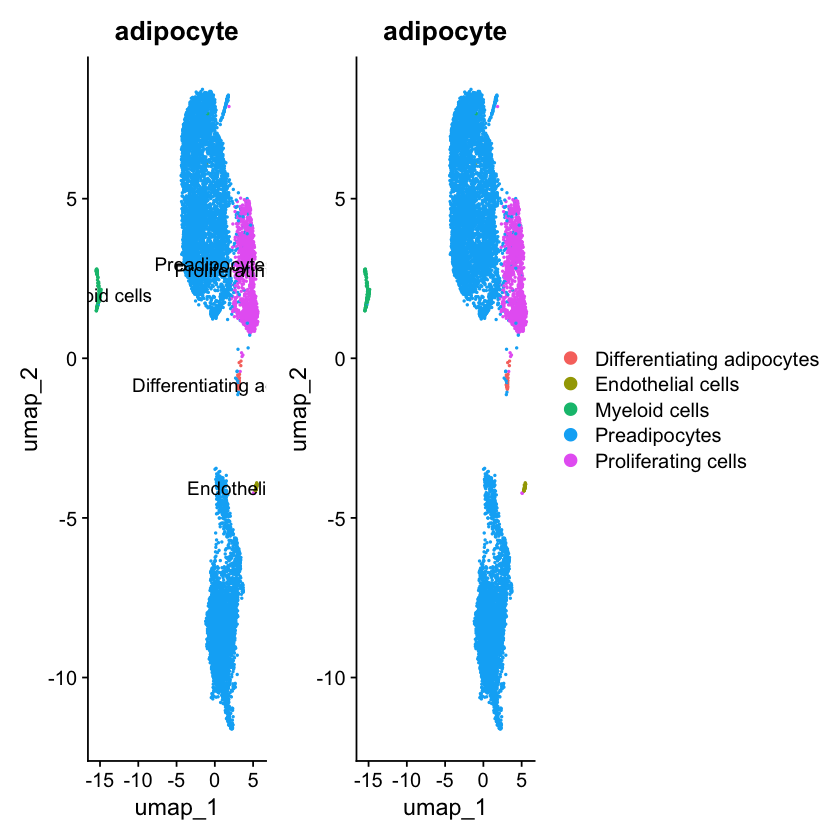

In [87]:
f3 <- DimPlot(adp_filt, group.by = "adipocyte", label = FALSE)

f2 | f3